# SOFI Stock Analysis (Learning Project)

This notebook documents my step-by-step process of learning how to analyze stocks using Python.

Each section builds on the previous one as I improve my understanding.

## 1. Basic Stock Price Analysis (SOFI)

/tmp/ipykernel_20738/3339795169.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price      Close   High    Low  Open    Volume
Ticker      SOFI   SOFI   SOFI  SOFI      SOFI
Date                                          
2023-01-03  4.50  4.750  4.430  4.65  29303200
2023-01-04  4.77  4.880  4.495  4.54  48731400
2023-01-05  4.63  4.730  4.560  4.66  30512000
2023-01-06  4.62  4.695  4.490  4.66  31589500
2023-01-09  4.82  5.000  4.670  4.67  50435000


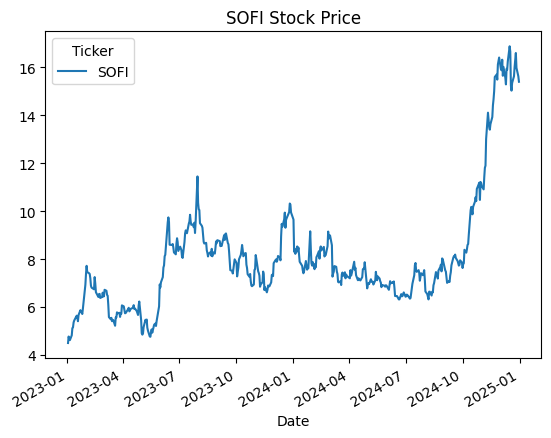

In [5]:
import yfinance as yf
import matplotlib.pyplot as plt

# Pick a company
ticker = "SOFI"

# Get data
data = yf.download(ticker, start="2023-01-01", end="2025-01-01")

# Show first rows
print(data.head())

# Plot closing price
data["Close"].plot(title=f"{ticker} Stock Price")
plt.show()

## 2. Comparing SOFI vs S&P 500

/tmp/ipykernel_20738/2137173286.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  2 of 2 completed


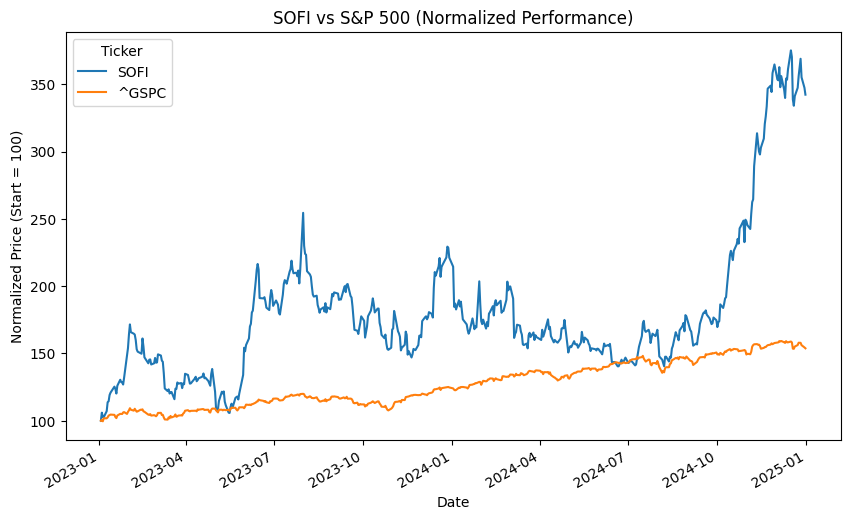

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = ["SOFI", "^GSPC"]
data = yf.download(tickers, start="2023-01-01", end="2025-01-01")

normalized = data["Close"] / data["Close"].iloc[0] * 100

normalized.plot(figsize=(10,6))
plt.title("SOFI vs S&P 500 (Normalized Performance)")
plt.ylabel("Normalized Price (Start = 100)")
plt.show()

This chart compares SOFI to the S&P 500 by setting both to the same starting value.

From this, I can start to see whether SOFI is outperforming or underperforming the broader market.

My first impression is that SOFI is more volatile than the market, which could mean it has a stronger reaction to specific news regarding the company and investor sentiment.

## 3. Volatility Comparison

In [7]:
import numpy as np

returns = data["Close"].pct_change()
volatility = returns.std()

print("Volatility (Daily Standard Deviation):")
print(volatility)

Volatility (Daily Standard Deviation):
Ticker
SOFI     0.038448
^GSPC    0.008106
dtype: float64


Volatility measures how much a stock moves from day to day.

A higher volatility number means the stock has larger price swings and may be riskier.

If SOFI has a higher volatility than the S&P 500, that supports the idea that SOFI is more sensitive to company-specific news and investor sentiment than the broader market.

## 4. Returns Analysis

Here I want to understand how much SOFI has actually returned over time compared to the market.

<Axes: title={'center': 'Cumulative Returns: SOFI vs S&P 500'}, xlabel='Date'>

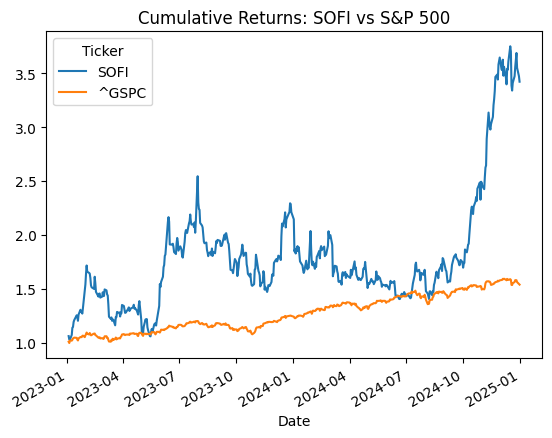

In [8]:
# Cumulative returns
cumulative_returns = (1 + returns).cumprod()

cumulative_returns.plot(title="Cumulative Returns: SOFI vs S&P 500")

Cumulative returns show how an initial investment would have grown over time.

This helps compare the actual performance instead of just price levels.

If SOFI outperforms the S&P 500, it could offer higher return potential.
If it underperforms, it suggests there's weaker long-term performance or higher volatility without reward.